In [2]:
##########################################
# A SCRIPT TO LOAD NCSS GFS ANALYSIS AND
# FOR BASIC MAP ANALYSIS
#
#
#
#
# (C) Kyle J Gillett 2025
##########################################

import warnings
warnings.filterwarnings("ignore")

# IMPORTS
import time as comp_time
import sys
import warnings
from siphon.catalog import TDSCatalog
from siphon.ncss import NCSS
from datetime import datetime, timedelta
from xarray.backends import NetCDF4DataStore
import xarray as xr




def gfs_forecast(center_lat=37.86, center_lon=-98.61, box_size=20, forecast_hours=[6, 12, 18, 24, 36, 48, 60, 72]):
    st = comp_time.time()
    
    print('ACCESSING GFS DATA...')
    
    # define dataset URL
    url = 'https://thredds.ucar.edu/thredds/catalog/grib/NCEP/GFS/Global_0p25deg/latest.xml'
    
    try:
        cat = TDSCatalog(url)
    except:
        sys.exit("NCSS URL FAILED -- GFS data may not be available at this time.")
    
    latest_ds = list(cat.datasets.values())[0]
    ncss = NCSS(latest_ds.access_urls['NetcdfSubset'])
    
    # Find analysis time
    start_time = ncss.metadata.time_span['begin']
    base_time = datetime.strptime(start_time, '%Y-%m-%dT%H:%M:%SZ')
    
    all_forecasts = {}
    
    for fh in forecast_hours:
        query_time = base_time + timedelta(hours=fh)
        query = ncss.query()
        query.time(query_time).accept('netcdf4')
        
        # Subset variables
        query.variables(
            'MSLP_Eta_model_reduction_msl',
            'Pressure_surface',
            'Geopotential_height_isobaric',
            'Temperature_isobaric',
            'Relative_humidity_isobaric',
            'Temperature_height_above_ground',
            'Relative_humidity_height_above_ground',
            'u-component_of_wind_height_above_ground', 'v-component_of_wind_height_above_ground',
            'u-component_of_wind_isobaric', 'v-component_of_wind_isobaric',
            'Convective_available_potential_energy_surface',
            'Storm_relative_helicity_height_above_ground_layer',
            'U-Component_Storm_Motion_height_above_ground_layer',
            'V-Component_Storm_Motion_height_above_ground_layer'
        ).add_lonlat()
        
        # Subset by lat-lon domain
        query.lonlat_box(north=58.415, west=-139.970, east=-57.269, south=16.209)
        
        # Fetch data
        ncss_data = ncss.get_data(query)

        raw_data = xr.open_dataset(NetCDF4DataStore(ncss_data)).metpy.parse_cf()
        
        all_forecasts[fh] = raw_data
        print(f'Loaded GFS forecast for +{fh} hours: {query_time}')
    
    elapsed_time = comp_time.time() - st
    print('ALL FORECASTS LOADED. Time elapsed:', comp_time.strftime("%H:%M:%S", comp_time.gmtime(elapsed_time)))
    
    return all_forecasts






In [15]:
datas[12]['reftime']

<xarray.DataArray 'reftime' ()> Size: 8B
array('2025-11-21T12:00:00.000000000', dtype='datetime64[ns]')
Coordinates:
    reftime    datetime64[ns] 8B 2025-11-21T12:00:00
    metpy_crs  object 8B Projection: latitude_longitude
Attributes:
    standard_name:  forecast_reference_time
    long_name:      GRIB reference time

############
SCRIPT RUNNING
############


Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.


    FINISHED 300HPA FLOW MAP


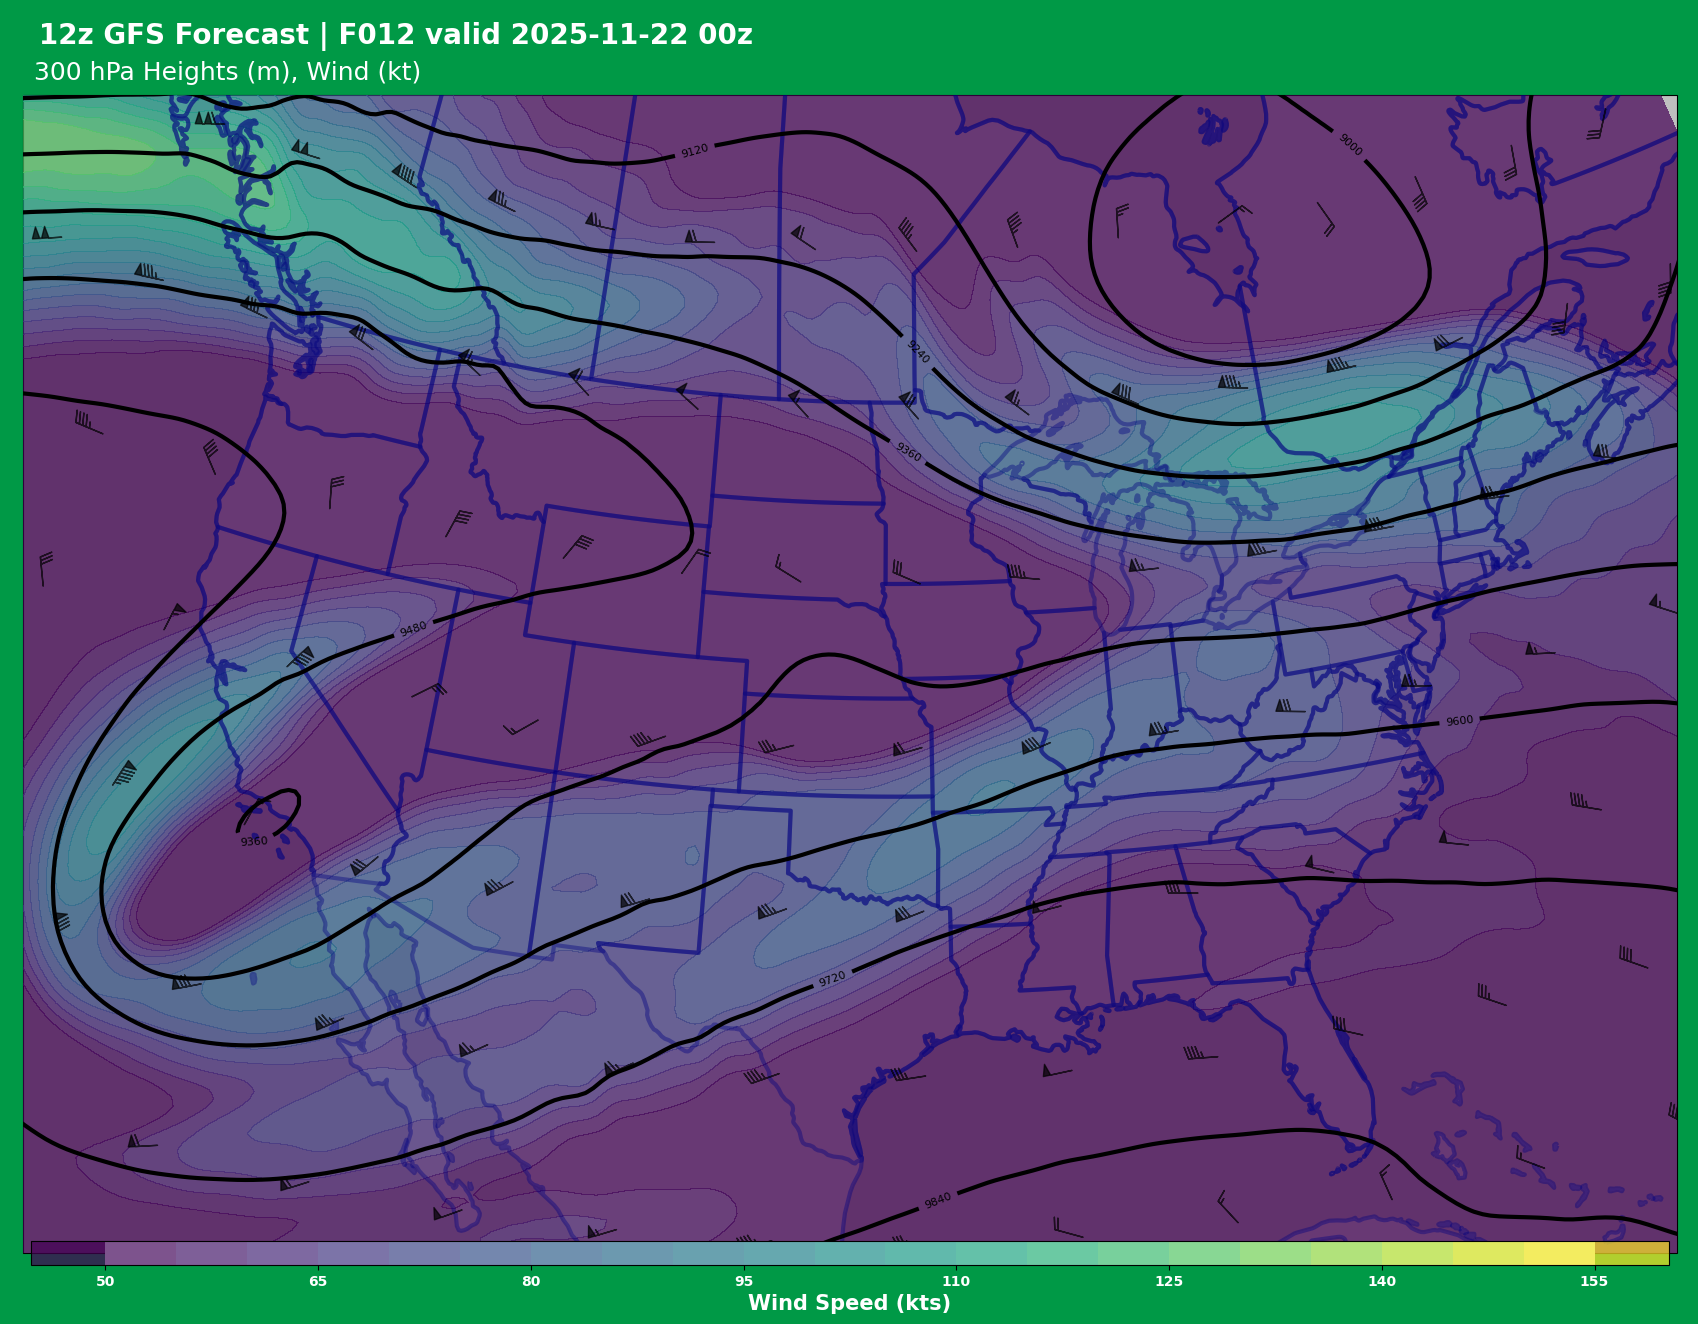

In [19]:
print("############\nSCRIPT RUNNING\n############")
import time as comp_time
st = comp_time.time()

import warnings
warnings.filterwarnings("ignore")

import scipy.ndimage as ndimage
import metpy.calc as mpcalc
from metpy.units import units
from metpy.interpolate import interpolate_to_isosurface
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import matplotlib.pyplot as plt
from datetime import datetime, timezone
import numpy as np
import sys
import os
import xarray as xr


# parse date information for sat data download
utc_date = datetime.now(timezone.utc)
utc_doy = utc_date.timetuple().tm_yday
if utc_doy < 100:
    utc_doy = f'0{utc_doy}'
else:
    utc_doy = str(utc_doy)
utc_now = [utc_date.strftime("%Y"), utc_date.strftime("%m"), utc_date.strftime("%d"), utc_date.strftime("%H"), utc_doy]





#############################################################################################################################################################################
#############################################################################################################################################################################
#############################################################################################################################################################################

# set up rap retrieval 
center_lat = 46.841203
center_lon = -98.777673
box_size   = 35
west = center_lon  - box_size
east = center_lon  + box_size
south = center_lat - box_size
north = center_lat + box_size

# pull rap data
#datas = gfs_forecast(box_size=box_size, forecast_hours=[12])

for fh, raw_data in datas.items():

    fh = str(fh).zfill(3)

    # LATS & LONS
    lats = raw_data.variables['latitude'][:]
    lons = raw_data.variables['longitude'][:]

    # PRES LEVS
    pres_levs = raw_data['isobaric'][:]
    pres_levs = pres_levs / 100

    # DATE INFO
    try:
        data_date = raw_data['time'].values[0]
    except:
        pass

    valid_date = f'{data_date}'
    run_date = f'{raw_data['reftime'].values}'


    # BASIC DATA EXTRACTION
    sigma = 1.5
    ghgt_iso = ndimage.gaussian_filter(raw_data.variables['Geopotential_height_isobaric'][0], sigma=sigma)
    temp_iso = ndimage.gaussian_filter(raw_data.variables['Temperature_isobaric'][0], sigma=sigma) - 273.15
    uwnd_iso = ndimage.gaussian_filter(raw_data.variables['u-component_of_wind_isobaric'][0], sigma=sigma) * 1.94384
    vwnd_iso = ndimage.gaussian_filter(raw_data.variables['v-component_of_wind_isobaric'][0], sigma=sigma) * 1.94384

    pres_sfc = ndimage.gaussian_filter(raw_data.variables['MSLP_Eta_model_reduction_msl'][0], sigma=sigma)
    temp_sfc = ndimage.gaussian_filter(raw_data.variables['Temperature_height_above_ground'][0], sigma=sigma) - 273.15
    uwnd_sfc = ndimage.gaussian_filter(raw_data.variables['u-component_of_wind_height_above_ground'][0], sigma=sigma) * 1.94384
    vwnd_sfc = ndimage.gaussian_filter(raw_data.variables['v-component_of_wind_height_above_ground'][0], sigma=sigma) * 1.94384
    relh_sfc = ndimage.gaussian_filter(raw_data.variables['Relative_humidity_height_above_ground'][0], sigma=sigma)
    dwpt_sfc = mpcalc.dewpoint_from_relative_humidity(temp_sfc*units.degC, relh_sfc*units.percent)


    #################################
    # CALCULATE FRONTOGENESIS
    ################################# 
    # using MetPy, compute frontogensis
    fgen = mpcalc.frontogenesis(raw_data['Temperature_isobaric'], 
                                raw_data['u-component_of_wind_isobaric'],
                                raw_data['v-component_of_wind_isobaric'],
                                latitude=raw_data['latitude'].values,longitude=raw_data['longitude'].values,crs=ccrs.PlateCarree())
    # convert units to delta deg C / 100 km / 3 hr
    fgen = fgen.metpy.convert_units('delta_degC/km/hour')*3*100
    # create `fgen_masked`, a DataArray of fgen values >2, all else are Nan
    fgen_masked = fgen.where(fgen > (2 * units('delta_degC/km/hour')))


    #################################
    # CALCULATE ADVECTION
    ################################# 
    # using MetPy, compute temperature advection
    adv = mpcalc.advection(raw_data['Temperature_isobaric'], 
                        raw_data['u-component_of_wind_isobaric'],
                        raw_data['v-component_of_wind_isobaric'],
                        latitude=raw_data['latitude'].values,longitude=raw_data['longitude'].values,crs=ccrs.PlateCarree())
    # convert units to delta deg C / hr
    adv = adv.metpy.convert_units('delta_degC/hour')
    # apply some smoothing to adv 
    adv = ndimage.gaussian_filter(adv, sigma=2, order=0) * units('K/sec')


    # use metpy to compute theta & add it into the `rap-data` DataSet
    raw_data['theta'] = mpcalc.potential_temperature(raw_data['isobaric'],raw_data['Temperature_isobaric'])

    # use metpy to compute latitude / longitude grid deltas (dx, dy) for PV calculation
    dx, dy = mpcalc.lat_lon_grid_deltas(raw_data['longitude'].values, raw_data['latitude'].values)

    # use metpy to compute PV and add it into the `rap_data` DataSet
    raw_data['pv'] = mpcalc.potential_vorticity_baroclinic(raw_data['theta'],
                                                            raw_data['isobaric'],
                                                            u=raw_data['u-component_of_wind_isobaric'],
                                                            v=raw_data['v-component_of_wind_isobaric'],
                                                            dx=dx[None, None, :, :], dy=dy[None, None, :, :],
                                                            latitude=raw_data['latitude'])

    thta_on_2pvu = interpolate_to_isosurface(raw_data['pv'].values, raw_data['theta'].values,  2*1e-6, bottom_up_search=True)
    u_on_2pvu    = interpolate_to_isosurface(raw_data['pv'][:,0,:,:].values, raw_data['u-component_of_wind_isobaric'][0,:,:,:].values, 2*1e-6, bottom_up_search=True)
    v_on_2pvu    = interpolate_to_isosurface(raw_data['pv'][:,0,:,:].values, raw_data['v-component_of_wind_isobaric'][0,:,:,:].values, 2*1e-6, bottom_up_search=True)

    #############################################################################################################################################################################
    #############################################################################################################################################################################
    #############################################################################################################################################################################
    #############################################################################################################################################################################
    #############################################################################################################################################################################
    #############################################################################################################################################################################
    #################################
    # BUILD 300 HPA MAP
    #################################
    fig, ax = build_map()

    # slice data
    plev300 = np.where(pres_levs == 300)[0][0]
    ghgt_300 = ghgt_iso[plev300]
    uwnd_300 = uwnd_iso[plev300]
    vwnd_300 = vwnd_iso[plev300]
    wdsp_300 = np.sqrt(uwnd_300**2 + vwnd_300**2)

    # plot 300 hpa heights
    contour = ax.contour(lons, lats, ghgt_300, np.arange(0, 12000, 120),
                    colors='black', linewidths=3.0, linestyles='-',
                    transform=ccrs.PlateCarree(), zorder=11)
    plt.clabel(contour, fontsize=8, inline=1, inline_spacing=10, fmt='%i',
            rightside_up=True, use_clabeltext=True)

    # plot 300 hpa wind speed
    contourf = ax.contourf(lons, lats, wdsp_300, np.arange(50, 160, 5), extend='both',
                    cmap='viridis', alpha=0.7, transform=ccrs.PlateCarree(), zorder=4)

    # plot 300 hpa wind barbs
    every = 20
    barbs = ax.barbs(lons.values[0::every], lats.values[0::every],
                    uwnd_300[0::every, 0::every], vwnd_300[0::every, 0::every],
                    length=6.5, alpha=0.7, transform=ccrs.PlateCarree(), zorder=12)

    # plot title, add one to the left with model name and data names, add another to the right with time info
    plt.figtext(0.08, 1.03, f'   {run_date[11:-16]}z GFS Forecast | F{fh} valid {valid_date[0:10]} {valid_date[11:-16]}z', weight='bold', ha='left', fontsize=20, color='white')
    plt.figtext(0.08, 1.00, f'   300 hPa Heights (m), Wind (kt)', ha='left', fontsize=18, color='white')
    plt.figtext(0.915, 1.04, f' ', ha='left', fontsize=20)
    # colorbar for filled contour
    cbar = plt.colorbar(contourf, aspect=70, fraction=0.02, ax=ax, orientation='horizontal', pad=-0.01, extendrect=True)
    cbar.set_label('Wind Speed (kts)', fontsize=15, color='white', fontweight='bold')
    cbar.ax.tick_params(labelcolor='white')
    for t in cbar.ax.get_xticklabels():
        t.set_fontweight('bold')

    # # add UND logo
    # from PIL import Image
    # img = Image.open('utils/images/und-logo.png')
    # #                  side-side  up-down  size   size
    # imgax = fig.add_axes([0.83, 1.01, 0.06, 0.06], anchor='SE', zorder=3)
    # plt.figtext(0.81, 0.995, f'ATMOSPHERIC SCIENCES', ha='left', weight='bold', fontsize=10, color='white')
    # imgax.imshow(img)
    # imgax.axis('off')

    # #plt.savefig("staged_figures/conus_rap_analysis/rap_300_flow.png", bbox_inches="tight")

    print("    FINISHED 300HPA FLOW MAP")
    #############################################################################################################################################################################
    #############################################################################################################################################################################
    #############################################################################################################################################################################



In [4]:
import scipy.ndimage as ndimage
import metpy.calc as mpcalc
from metpy.units import units
from metpy.interpolate import interpolate_to_isosurface
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import matplotlib.pyplot as plt
from datetime import datetime, timezone
import numpy as np
import sys
import os
import xarray as xr

def build_map(extent=[-122, -73, 21, 56], projection=ccrs.LambertConformal(), style='light'):
    fig = plt.figure(figsize=(20, 12))
    fig.set_facecolor('#009946')
    ax = plt.axes(projection=projection)

    ax.set_extent(extent)
    ax.set_box_aspect(0.7)

    if style == 'light':
        color = 'gray'
        alpha = 0.5
    else:
        color = 'black'
        alpha = 0.8

    ax.add_feature(cfeature.STATES, edgecolor='navy', alpha=0.4, linestyle='-', linewidth=3, zorder=10)
    ax.add_feature(cfeature.LAND, facecolor=color, alpha=alpha, zorder=1)
    ax.add_feature(cfeature.OCEAN, facecolor=color, alpha=alpha + 0.2, zorder=0)
    ax.add_feature(cfeature.COASTLINE, color='navy', alpha=0.4, linestyle='-', linewidth=3, zorder=11)

    plt.tight_layout()

    return fig, ax
#############################################################################################################################################################################
#############################################################################################################################################################################
#############################################################################################################################################################################


In [ ]:
#############################################################################################################################################################################
    #############################################################################################################################################################################
    #############################################################################################################################################################################
    #################################
    # BUILD 300 HPA MAP
    #################################
    fig, ax = build_map()

    # slice data
    plev300 = np.where(pres_levs == 300)[0][0]
    ghgt_300 = ghgt_iso[plev300]
    uwnd_300 = uwnd_iso[plev300]
    vwnd_300 = vwnd_iso[plev300]
    wdsp_300 = np.sqrt(uwnd_300**2 + vwnd_300**2)

    # plot 300 hpa heights
    contour = ax.contour(lons, lats, ghgt_300, np.arange(0, 12000, 120),
                    colors='black', linewidths=3.0, linestyles='-',
                    transform=ccrs.PlateCarree(), zorder=11)
    plt.clabel(contour, fontsize=8, inline=1, inline_spacing=10, fmt='%i',
            rightside_up=True, use_clabeltext=True)

    # plot 300 hpa wind speed
    contourf = ax.contourf(lons, lats, wdsp_300, np.arange(50, 160, 5), extend='both',
                    cmap=wdsp_cmap, alpha=0.7, transform=ccrs.PlateCarree(), zorder=4)

    # plot 300 hpa wind barbs
    every = 20
    barbs = ax.barbs(lons.values[0::every, 0::every], lats.values[0::every, 0::every],
                    uwnd_300[0::every, 0::every], vwnd_300[0::every, 0::every],
                    length=6.5, alpha=0.7, transform=ccrs.PlateCarree(), zorder=12)

    # plot title, add one to the left with model name and data names, add another to the right with time info
    plt.figtext(0.08, 1.03, f'   GFS F{fh} 300 hPa Analysis | {valid_date[0:10]} {valid_date[11:-13]}z', weight='bold', ha='left', fontsize=20, color='white')
    plt.figtext(0.08, 1.00, f'   Heights (m), Wind (kt)', ha='left', fontsize=18, color='white')
    plt.figtext(0.915, 1.04, f' ', ha='left', fontsize=20)
    # colorbar for filled contour
    cbar = plt.colorbar(contourf, aspect=70, fraction=0.02, ax=ax, orientation='horizontal', pad=-0.01, extendrect=True)
    cbar.set_label('Wind Speed (kts)', fontsize=15, color='white', fontweight='bold')
    cbar.ax.tick_params(labelcolor='white')
    for t in cbar.ax.get_xticklabels():
        t.set_fontweight('bold')

    # add UND logo
    from PIL import Image
    img = Image.open('utils/images/und-logo.png')
    #                  side-side  up-down  size   size
    imgax = fig.add_axes([0.83, 1.01, 0.06, 0.06], anchor='SE', zorder=3)
    plt.figtext(0.81, 0.995, f'ATMOSPHERIC SCIENCES', ha='left', weight='bold', fontsize=10, color='white')
    imgax.imshow(img)
    imgax.axis('off')

    plt.savefig("staged_figures/conus_rap_analysis/rap_300_flow.png", bbox_inches="tight")

    print("    FINISHED 300HPA FLOW MAP")
    #############################################################################################################################################################################
    #############################################################################################################################################################################
    #############################################################################################################################################################################


In [21]:
import scipy.ndimage as ndimage
import metpy.calc as mpcalc
from metpy.units import units

for fh, raw_data in datas.items():

    # set up rap retrieval 
    center_lat = 46.841203
    center_lon = -98.777673
    box_size   = 35
    west = center_lon  - box_size
    east = center_lon  + box_size
    south = center_lat - box_size
    north = center_lat + box_size

    # LATS & LONS
    lats = raw_data.variables['latitude'][:]
    lons = raw_data.variables['longitude'][:]

    # PRES LEVS
    pres_levs = raw_data['isobaric'][:]
    pres_levs = pres_levs / 100

    # DATE INFO
    try:
        data_date = raw_data['time'].values[0]
    except:
        try:
            for i in time:
                data_date = raw_data[f'time{i}'].values[0]
        except:
            pass
        pass

    valid_date = f'{data_date}'


    # BASIC DATA EXTRACTION
    sigma = 1.5
    ghgt_iso = ndimage.gaussian_filter(raw_data.variables['Geopotential_height_isobaric'][0], sigma=sigma)
    temp_iso = ndimage.gaussian_filter(raw_data.variables['Temperature_isobaric'][0], sigma=sigma) - 273.15
    uwnd_iso = ndimage.gaussian_filter(raw_data.variables['u-component_of_wind_isobaric'][0], sigma=sigma) * 1.94384
    vwnd_iso = ndimage.gaussian_filter(raw_data.variables['v-component_of_wind_isobaric'][0], sigma=sigma) * 1.94384

    pres_sfc = ndimage.gaussian_filter(raw_data.variables['MSLP_Eta_model_reduction_msl'][0], sigma=sigma) / 100
    temp_sfc = ndimage.gaussian_filter(raw_data.variables['Temperature_height_above_ground'][0], sigma=sigma) - 273.15
    uwnd_sfc = ndimage.gaussian_filter(raw_data.variables['u-component_of_wind_height_above_ground'][0], sigma=sigma) * 1.94384
    vwnd_sfc = ndimage.gaussian_filter(raw_data.variables['v-component_of_wind_height_above_ground'][0], sigma=sigma) * 1.94384
    relh_sfc = ndimage.gaussian_filter(raw_data.variables['Relative_humidity_height_above_ground'][0], sigma=sigma)
    dwpt_sfc = mpcalc.dewpoint_from_relative_humidity(temp_sfc*units.degC, relh_sfc*units.percent)


############
SCRIPT RUNNING
############
    FINISHED ACE FIGURE
############
SCRIPT FINISHED: time: 00:00:01
############


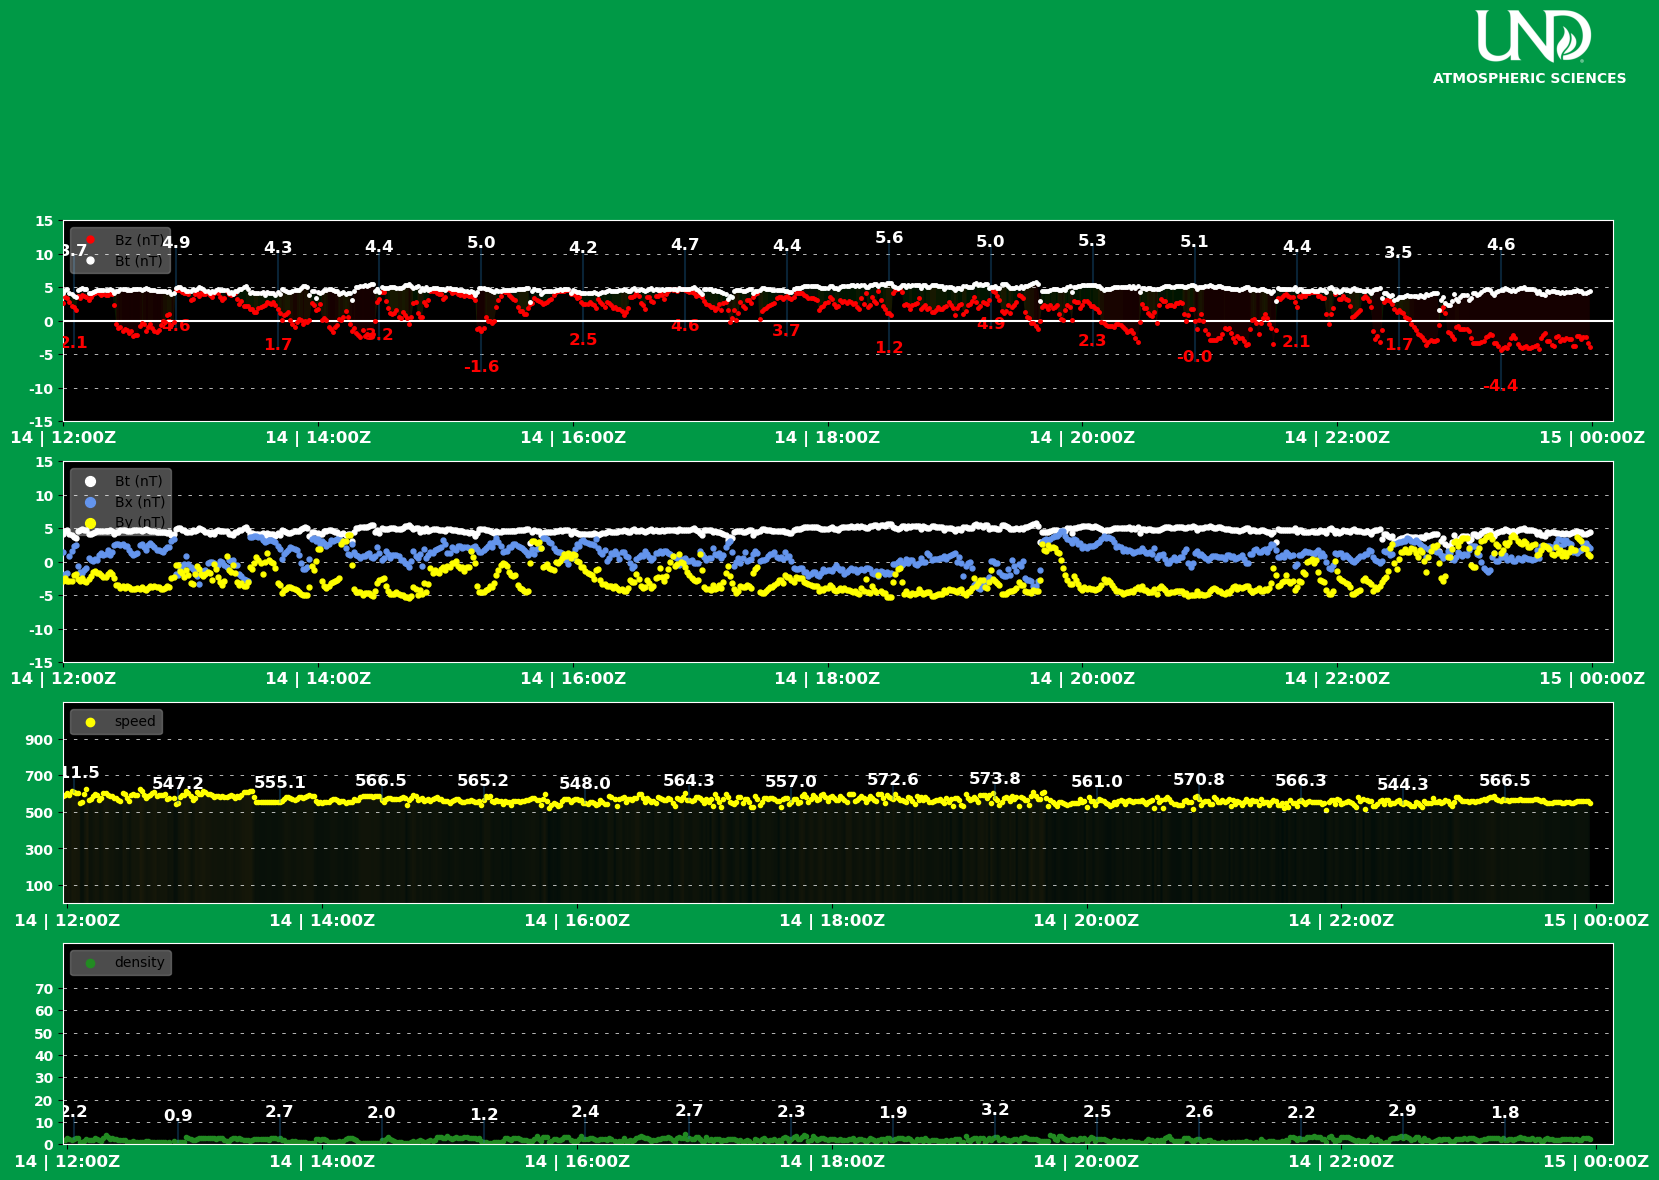

In [9]:
print("############\nSCRIPT RUNNING\n############")
import time as comp_time
st = comp_time.time()

import warnings
warnings.filterwarnings("ignore")

import matplotlib
import matplotlib.pyplot as plt
from matplotlib.patheffects import withStroke
import matplotlib.dates as mdates
from datetime import datetime, timedelta
import numpy as np
import math
from urllib.request import urlopen
from PIL import Image
import sys
import os

# # get script dir
# script_dir = os.path.dirname(os.path.abspath(__file__))

# # get the parent dir 
# project_root = os.path.abspath(os.path.join(script_dir, ".."))

# if project_root not in sys.path:
#     sys.path.append(project_root)
import sys, os
sys.path.append(os.path.abspath(os.path.join(os.getcwd(), '..')))  # add parent dir
from get_data.get_spacewx_data import get_ace_data, get_kp_data

data = get_ace_data()

time_range = 12

### TIME UTILS ###
#####################################################
def time_utils(data, time_range=6, src='magswe'):

    mag_start_date_idx = find_nearest(data['mag_dates'], (data['mag_dates'][-1] - timedelta(hours=time_range)).replace(second=0, microsecond=0))
    mag_end_date_idx   = -1 
    pam_start_date_idx = find_nearest(data['pam_dates'], (data['pam_dates'][-1] - timedelta(hours=time_range)).replace(second=0, microsecond=0))
    pam_end_date_idx   = -1 

    travel_time = int(((1500000)/(find_latest_vals(data['speed']))/60))
    travel_time_delta = data['pam_dates'][pam_end_date_idx] - timedelta(minutes=travel_time)
    travel_time_delta_text = data['pam_dates'][pam_end_date_idx] - timedelta(minutes=travel_time+2)
    
    return [mag_start_date_idx, mag_end_date_idx], [pam_start_date_idx, pam_end_date_idx], [travel_time_delta, travel_time_delta_text]
    



### CHECK FOR VALID DICT KEYS ###
#####################################################
def check_dict_keys(dictionary, keys):
    for key in keys:
        if key not in dictionary:
            raise KeyError(f"INCOMPLETE DATA -- '{key}' data missing -- the data you are trying to plot may not be meant for this plot style, or there is incomplete data")
    

    
    
### REPLACE MISSIN DATA WITH NAN ###
#####################################################    
def replace_missing(array):
    for item in range(0, len(array)):
        if array[item] <= -999.9:
            array[item] = np.nan
    return array


### SIMPLE NAN INTERP FUNCTION ###
#####################################################
def interpolate_nans(array):
    nan_indices = np.isnan(array)
    valid_indices = ~nan_indices
    array[nan_indices] = np.interp(np.flatnonzero(nan_indices), np.flatnonzero(valid_indices), array[valid_indices])
    return array


### FIND IMF Y-LIMIT ###
#####################################################
def find_imf_limit(bt, bz):
    
    bt, bz = replace_missing(bt), replace_missing(bz)  
    max_val = np.nanmax(np.concatenate((abs(bt), abs(bz))))
    nearest_5 = int(math.ceil(max_val / 5.0)) * 5
    
    if (nearest_5 - max_val) <= 3:
        return (nearest_5 + 5) + 5
    else:
        return (nearest_5) + 5
    
     
    
### FIND NEAREST VALUE ###
#####################################################    
def find_nearest(array, value):
        array = np.asarray(array)
        idx = (np.abs(array - value)).argmin()
        return idx
    
    
    
### BUILD SWPC AURORA COLORMAP ###
#####################################################    
def build_aurora_cmap(): 
    from colour import Color
    from matplotlib.colors import LinearSegmentedColormap
    from matplotlib.colors import ListedColormap
    
    color_list = ['#819b7c', '#5ea25c', '#3ba93a', '#01de00', '#6afd00', '#f1ff01', '#ffc900', '#fe8e00', '#fd3300', '#e80001', '#d80000',  '#d80000',  '#d80000',  '#d80000']

    aurora_cmap = ListedColormap([Color(c1).rgb for c1 in color_list ], 'my_list' )
    
    aurora_cmap_r = ListedColormap(aurora_cmap.colors[::-1])
    
    return aurora_cmap, aurora_cmap_r


### COMPUTE CURRENT VALUES ###
#####################################################
def find_latest_vals(data, bz=False):
    
    for item in reversed(data.tolist()):
        if not math.isnan(item):
            latest = item
            break
    # return -9999
    
    if bz == True:
        if latest > 0:
            bz_dir = 'NORTH'
        else:
            bz_dir = 'SOUTH'
        
        return np.round(latest,1), bz_dir
    else:
        return np.round(latest,1)

    
    
### CREATE AURORAL ACTIVITY STR ###
#####################################################
def find_g_level(kp_data):
    
    kp_data = float(kp_data[-1])
    
    g_levels = {
        0:' ', 1:' ', 2:' ', 3:' ', 4:' ',
        5:'| G1', 6:'| G2', 7:'| G3', 8:'| G4', 9:'| G5'
    }

    G = g_levels[int(kp_data)]

    if kp_data <= 3:
        activity = f'Quiet {G}'
    elif kp_data > 3 and a < 5:
        activity = f'Minor {G}'
    elif kp_data >= 5 and a < 7:
        activity = f'Moderate {G}'
    elif kp_data >= 7 and a < 9:
        activity = f'Active {G}'
    elif kp_data >= 9:
        activity = f'Very Active | {G}'
        
    return activity




#############
# BUILD MAG/SWE PLOT #
##################################

# MAKE SOME DATA CORRECTIONS AND TIME LOGIC CALCS
# USE UTIL FUNCTIONS 
mag_idx, pam_idx, travel_time = time_utils(data, time_range)

# get SWPC aurora colormap
aurora_cmap, aurora_cmap_r = build_aurora_cmap()

# build valid-date-string
valid_str = f"VALID: {data['mag_dates'][-1].strftime('%H:%M')}Z - {str.upper(data['mag_dates'][-1].strftime('%h'))} {data['mag_dates'][-1].strftime('%d')} {data['mag_dates'][-1].strftime('%Y')}"

# get KP data and current auroral activity 
kp_data = get_kp_data()
activity_str = find_g_level(kp_data['kp_index'])

# annotation increment 
ann_idx = time_range*4


data['density_intrp'] = interpolate_nans(replace_missing(data['density']))
data['speed_intrp'] = interpolate_nans(replace_missing(data['speed']))
data['bz_intrp'] = interpolate_nans(replace_missing(data['bz']))
data['bt_intrp'] = interpolate_nans(replace_missing(data['bt']))
data['by_intrp'] = interpolate_nans(replace_missing(data['by']))
data['bx_intrp'] = interpolate_nans(replace_missing(data['bx']))

#############
# BUILD FIGURE #
##################################

#=======================================================================================================================#
# DECLARE BASIC FIGURE PROPERTIES 
fig, (ax1, ax2, ax3, ax4) = plt.subplots(4, 1, figsize=(20, 12), linewidth=10, edgecolor='#009946')
fig.set_facecolor('#009946')

# DECLARE BASIC SUBPLOT PROPERTIES
for ax in [ax1, ax2, ax3, ax4]:
    ax.set_facecolor('black')
    ax.tick_params(axis='x', labelsize=12, labelcolor='white')
    for label in ax.get_xticklabels():
        label.set_fontweight('bold')
    ax.patch.set_alpha(1)
    ax.margins(0)
    ax.xaxis.set_major_formatter((mdates.DateFormatter('%d'+' | '+'%H:%M'+'Z')))
    ax.grid(which='major', axis='y', linestyle=(0, (5, 10)), color='white', linewidth=0.5)
    ax.spines["top"].set_color("white")
    ax.spines["left"].set_color("white")
    ax.spines["right"].set_color("white")
    ax.spines["bottom"].set_color("white")
    ax.spines["bottom"].set_color("white")
    #ax.axvline(x=travel_time[0], color='lightblue', linestyle='--')
#=======================================================================================================================#




#############
# PLOT DATA #
##################################

#=======================================================================================================================#    
# PLOT AXIS 1 DATA (MAGNETOMETER)
# use some simple math to find dynamic axis limits 
limit = find_imf_limit(data['bt'][mag_idx[0]:mag_idx[1]], data['bz'][mag_idx[0]:mag_idx[1]])
lbl1, lbl2, lbl3 = int(limit/3), int(limit/3) + int(limit/3), int(limit/3) + int(limit/3) + int(limit/3) 

ax1.set_ylim(-limit, limit)
ax1.set_yticks([-lbl3, -lbl2, -lbl1, 0, lbl1, lbl2, lbl3])
ax1.set_yticklabels([str(-lbl3), str(-lbl2), str(-lbl1), '0', str(lbl1), str(lbl2), str(lbl3)], color='white', weight='bold')
ax1.set_xlim(data['mag_dates'][mag_idx[0]], data['mag_dates'][mag_idx[1]] + timedelta(minutes=10))

ax1.axhline(y=0, color='white', linestyle='-', zorder=9)

# plot data 
ax1.plot(data['mag_dates'][mag_idx[0]:mag_idx[1]], data['bz'][mag_idx[0]:mag_idx[1]], 
            'r.', markersize=5, alpha=1, zorder=10, label='Bz (nT)')
ax1.plot(data['mag_dates'][mag_idx[0]:mag_idx[1]], data['bt'][mag_idx[0]:mag_idx[1]],
            'w.', markersize=5, alpha=1, zorder=10, label='Bt (nT)')


# data fill
polygon = ax1.fill_between(data['mag_dates'][mag_idx[0]:mag_idx[1]], data['bz_intrp'][mag_idx[0]:mag_idx[1]],  data['bt_intrp'][mag_idx[0]:mag_idx[1]], interpolate=True, color='none', alpha=0.1, zorder=3)
verts   = np.vstack([p.vertices for p in polygon.get_paths()])
filling = ax1.imshow(data['bz_intrp'][mag_idx[0]:mag_idx[1]].reshape(1, -1), cmap=aurora_cmap_r, aspect='auto', interpolation_stage='data', alpha=0.1,
                    extent=[verts[:, 0].min(), verts[:, 0].max(), verts[:, 1].min(), verts[:, 1].max()], label='IMF')
filling.set_clip_path(polygon.get_paths()[0], transform=ax1.transData)


# annotate data
for x, y in zip(data['mag_dates'][mag_idx[0]:mag_idx[1]][5 : : ann_idx], data['bz'][mag_idx[0]:mag_idx[1]].tolist()[5 : : ann_idx]):
    ax1.text(x, y-6, f"{np.round(y, 1)}", weight='bold', fontsize=12, color='red', alpha=1, ha='center', clip_on=True)
    ax1.add_line(matplotlib.lines.Line2D([x, x], [y, y-6], alpha=0.3))

for x, y in zip(data['mag_dates'][mag_idx[0]:mag_idx[1]][5 : : ann_idx], data['bt'][mag_idx[0]:mag_idx[1]].tolist()[5 : : ann_idx]):
    ax1.text(x, y+6, f"{np.round(y, 1)}", weight='bold', fontsize=12, color='white', alpha=1, ha='center', clip_on=True)
    ax1.add_line(matplotlib.lines.Line2D([x, x], [y, y+6], alpha=0.3))
    
leg = ax1.legend(loc='upper left', framealpha=0.3, markerscale=2)
#=======================================================================================================================#




#=======================================================================================================================#
# PLOT AXIS 2 DATA (MAGNETOMETER)
# use some simple math to find dynamic axis limits 
limit = find_imf_limit(data['bt'][mag_idx[0]:mag_idx[1]], data['bz'][mag_idx[0]:mag_idx[1]])
lbl1, lbl2, lbl3 = int(limit/3), int(limit/3) + int(limit/3), int(limit/3) + int(limit/3) + int(limit/3) 

ax2.set_ylim(-limit, limit)
ax2.set_yticks([-lbl3, -lbl2, -lbl1, 0, lbl1, lbl2, lbl3])
ax2.set_yticklabels([str(-lbl3), str(-lbl2), str(-lbl1), '0', str(lbl1), str(lbl2), str(lbl3)], color='white', weight='bold')
ax2.set_xlim(data['mag_dates'][mag_idx[0]], data['mag_dates'][mag_idx[1]] + timedelta(minutes=10))

ax2.scatter(data['mag_dates'][mag_idx[0]:mag_idx[1]], data['bt'][mag_idx[0]:mag_idx[1]],
            color='white', marker='.', s=50, alpha=1, zorder=10, label='Bt (nT)')
ax2.scatter(data['mag_dates'][mag_idx[0]:mag_idx[1]], data['bx'][mag_idx[0]:mag_idx[1]], 
            color='cornflowerblue', marker='.', s=50, alpha=1, zorder=10, label='Bx (nT)')
ax2.scatter(data['mag_dates'][mag_idx[0]:mag_idx[1]], data['by'][mag_idx[0]:mag_idx[1]],
            color='yellow', marker='.', s=50, alpha=1, zorder=10, label='By (nT)')

ax2.legend(loc='upper left', framealpha=0.3, markerscale=2)
#=======================================================================================================================#




#=======================================================================================================================#
# PLOT AXIS 3 DATA (SOLAR WIND SPEED)
ax3.set_ylim(0, 1100)
ax3.set_yticks([100, 300, 500, 700, 900])
ax3.set_yticklabels(['100', '300', '500', '700', '900'], color='white', weight='bold')
ax3.set_xlim(data['pam_dates'][pam_idx[0]], data['pam_dates'][pam_idx[1]] + timedelta(minutes=10))

# plot data 
ax3.scatter(data['pam_dates'][pam_idx[0]:pam_idx[1]], data['speed'][pam_idx[0]:pam_idx[1]], 
            marker='.', color='yellow', alpha=1, label ='speed')

# data fill
polygon = ax3.fill_between(data['pam_dates'][pam_idx[0]:pam_idx[1]], 0, data['speed_intrp'][pam_idx[0]:pam_idx[1]], interpolate=True, color='none', alpha=0.1, zorder=3)
verts = np.vstack([p.vertices for p in polygon.get_paths()])
filling = ax3.imshow(data['speed_intrp'][pam_idx[0]:pam_idx[1]].reshape(1, -1), cmap='summer', aspect='auto', interpolation_stage='data', alpha=0.1,
                    extent=[verts[:, 0].min(), verts[:, 0].max(), verts[:, 1].min(), verts[:, 1].max()])
filling.set_clip_path(polygon.get_paths()[0], transform=ax3.transData)

# annotate data
for x, y in zip(data['pam_dates'][pam_idx[0]:pam_idx[1]][5 : : ann_idx], data['speed'][pam_idx[0]:pam_idx[1]].tolist()[5 : : ann_idx]):
    ax3.text(x, y+80, f"{np.round(y, 1)}", weight='bold', fontsize=12, color='white', alpha=1, ha='center',clip_on=True)
    ax3.add_line(matplotlib.lines.Line2D([x, x], [y, y+80], alpha=0.3))
    
ax3.legend(loc='upper left', framealpha=0.3, markerscale=2)
#======================================================================================================================#




#======================================================================================================================#
# PLOT AXIS 4 DATA (SOLAR WIND DENSITY)
ax4.set_ylim(0, 90)
ax4.set_yticks([0, 10, 20, 30, 40, 50, 60, 70])
ax4.set_yticklabels(['0', '10', '20', '30', '40', '50', '60', '70'], color='white', weight='bold')
ax4.set_xlim(data['pam_dates'][pam_idx[0]], data['pam_dates'][pam_idx[1]] + timedelta(minutes=10))

# plot data 
ax4.scatter(data['pam_dates'][pam_idx[0]:pam_idx[1]], data['density'][pam_idx[0]:pam_idx[1]],
            marker='.', color='forestgreen', alpha=1, label ='density')

# data fill
polygon = ax4.fill_between(data['pam_dates'][pam_idx[0]:pam_idx[1]], 0, data['density_intrp'][pam_idx[0]:pam_idx[1]], interpolate=True, color='none', alpha=0.1, zorder=3)
verts = np.vstack([p.vertices for p in polygon.get_paths()])
filling = ax4.imshow(data['density_intrp'][pam_idx[0]:pam_idx[1]].reshape(1, -1), cmap='Greens', aspect='auto', interpolation_stage='data', alpha=0.1,
                        extent=[verts[:, 0].min(), verts[:, 0].max(), verts[:, 1].min(), verts[:, 1].max()])
filling.set_clip_path(polygon.get_paths()[0], transform=ax4.transData)

# annotate data
for x, y in zip(data['pam_dates'][pam_idx[0]:pam_idx[1]][5 : : ann_idx], data['density'][pam_idx[0]:pam_idx[1]].tolist()[5 : : ann_idx]):
    ax4.text(x, y+10, f"{np.round(y, 1)}", weight='bold', fontsize=12, color='white', alpha=1, ha='center',clip_on=True)
    ax4.add_line(matplotlib.lines.Line2D([x, x], [y, y+10], alpha=0.3))
    
ax4.legend(loc='upper left', framealpha=0.3, markerscale=2)
#=====================================================================================================================#




# ### ALL PLOT TITLES ###
# ######################################
# plt.figtext(0.10, 1, f"{str.upper(data['meta']['sat-name'])} | 1MIN MAGNETOMETER & SWEPAM", 
#             ha='left', weight='bold', fontsize=18, color='yellow')
# plt.figtext(0.98, 1,  f"IMF (nT) | Bt: {find_latest_vals(data['bt_intrp'])}, Bz: {find_latest_vals(data['bz_intrp'])} {find_latest_vals(data['bz_intrp'], bz=True)[1]}   ", 
#             ha='right', weight='bold', fontsize=18, color='yellow')
# plt.figtext(0.98, 0.75,  f"IMF STRENGTH & FLUX ROPE CONFIGURATIONS (nT) | Bt, Bx, By   ",
#             ha='right', weight='bold', fontsize=18, color='yellow')
# plt.figtext(0.98, 0.50,  f"SOLAR WIND SPEED (km/s) | CURRENT: {find_latest_vals(data['speed_intrp'])}   ", 
#             ha='right', weight='bold', fontsize=18, color='yellow')
# plt.figtext(0.98, 0.252, f"SOLAR WIND DENSITY (cm^-3) | CURRENT: {find_latest_vals(data['density_intrp'])}   ", 
#             ha='right', weight='bold', fontsize=18, color='yellow')
# plt.figtext(0.10, 1.045, f"AURORAL ACTIVITY SUMMARY", 
#             ha='left', weight='bold', fontsize=27, color='white')
# plt.figtext(0.10, 1.025, valid_str, 
#             ha='left', weight='bold', fontsize=17, color='white')
# plt.figtext(0.98, 1.03,  f"ACTIVITY: {str.upper(activity_str)}", 
#             ha='right', weight='bold', fontsize=20, color='white')
# plt.figtext(0.03, -0.01, f"'STEVEPY' SPACE WEATHER DATA ANALYSIS TOOL |", 
#             weight='bold', color='yellow', fontsize=12, ha='left', alpha=0.6)
# plt.figtext(0.268, -0.01, f"  (C) KYLE J GILLETT 2024, CENTRAL MICHIGAN UNIVERSITY | BETA VERSION, AVAILABLE SOON", 
#             weight='bold', color='yellow', fontsize=9, ha='left', alpha=0.6)

# plt.figtext(-0.01, 1.07, ' ')
# plt.figtext(1, -0.02, ' ')

img = Image.open('../utils/images/und-logo.png')
#                  side-side  up-down  size   size
imgax = fig.add_axes([0.83, 1.01, 0.06, 0.06], anchor='SE', zorder=3)
plt.figtext(0.81, 0.995, f'ATMOSPHERIC SCIENCES', ha='left', weight='bold', fontsize=10, color='white')
imgax.imshow(img)
imgax.axis('off')



print("    FINISHED ACE FIGURE")

    
#############################################################################################################################################################################
#############################################################################################################################################################################
#############################################################################################################################################################################



elapsed_time = comp_time.time() - st
print(f"############\nSCRIPT FINISHED: time: {comp_time.strftime("%H:%M:%S", comp_time.gmtime(elapsed_time))}\n############")

(np.float64(-0.5), np.float64(929.5), np.float64(424.5), np.float64(-0.5))

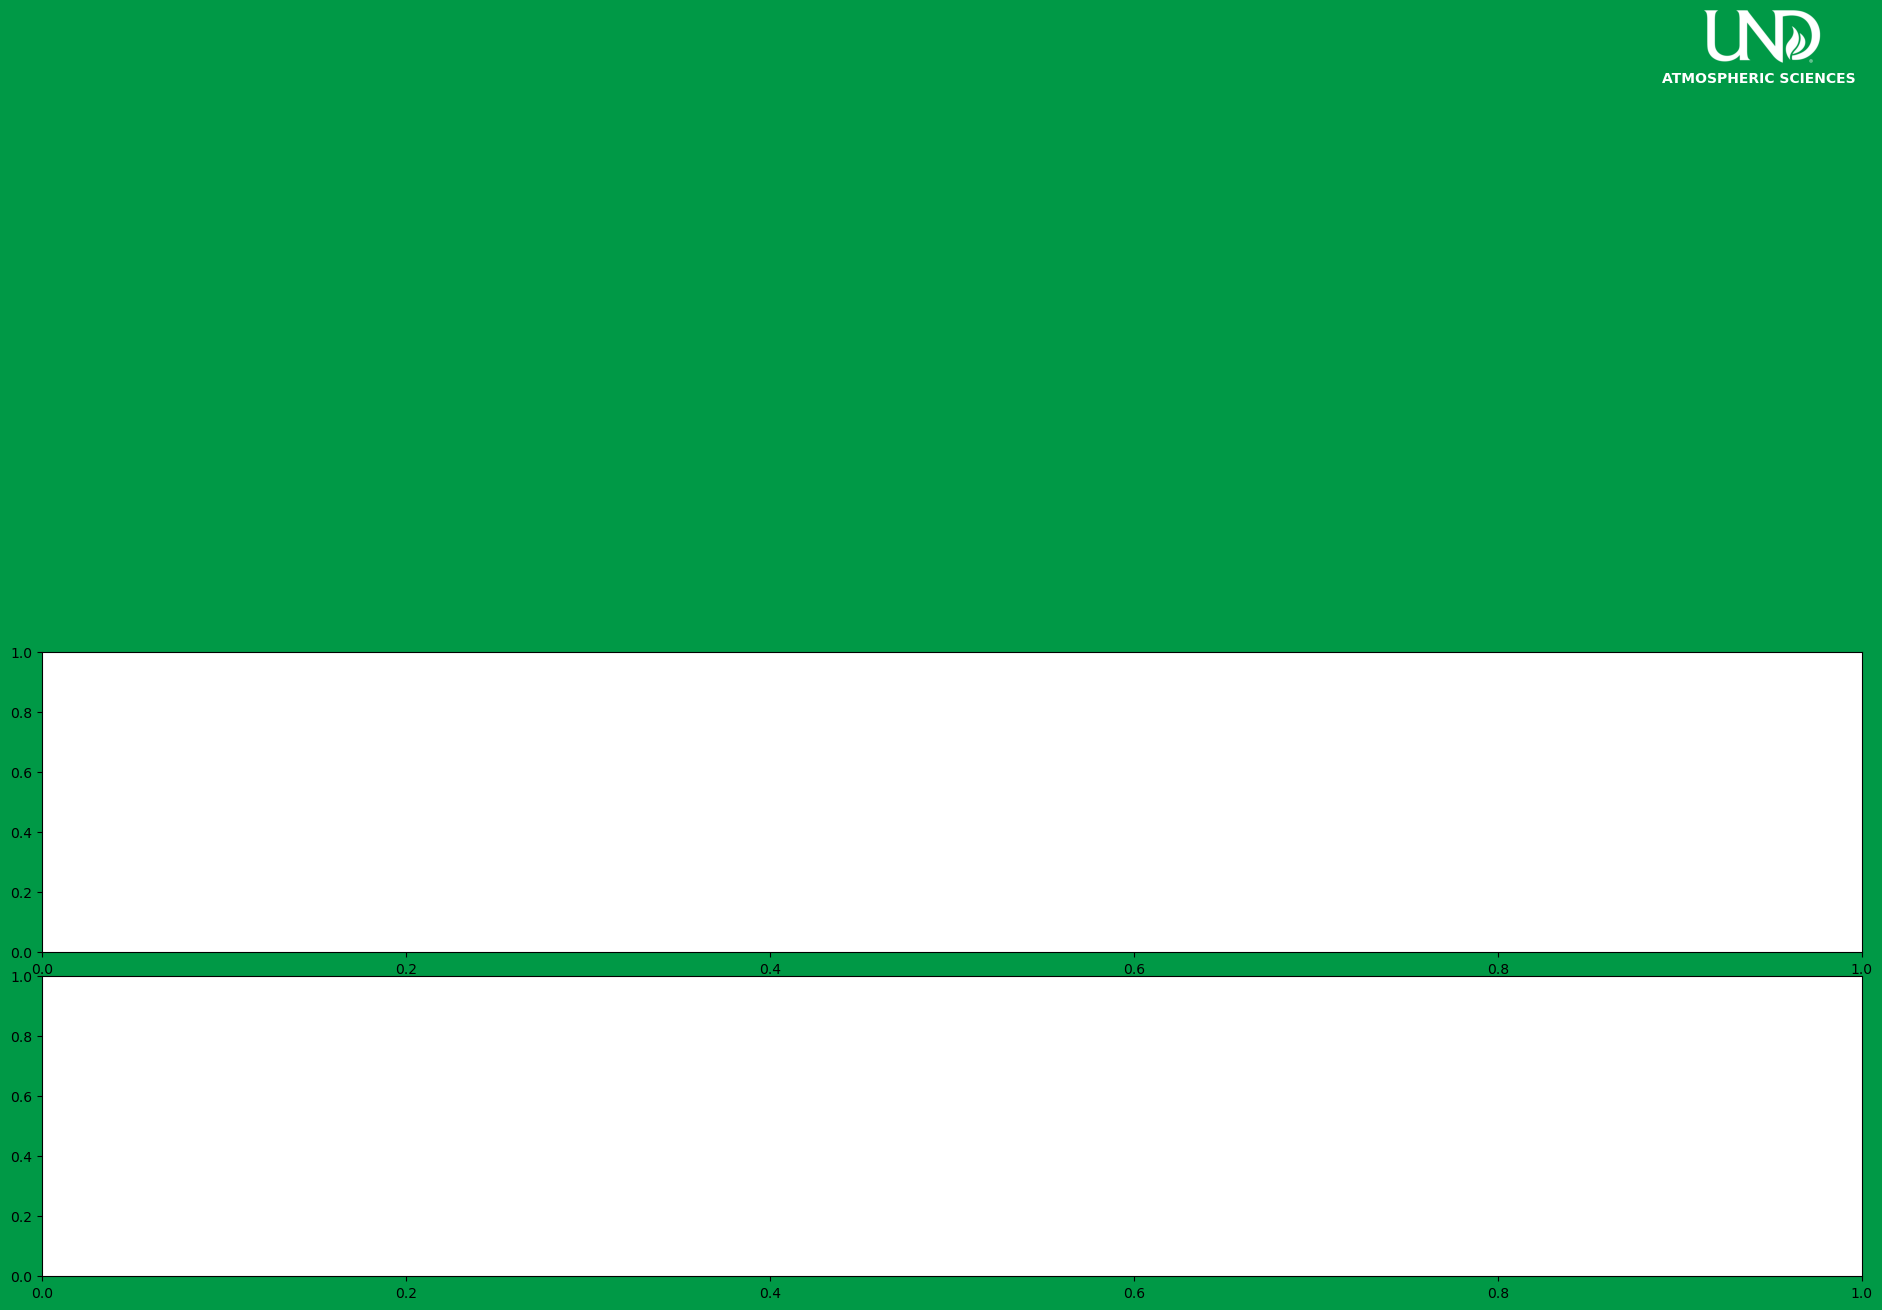

In [ ]:
fig = plt.figure(figsize=(20, 12))
fig.set_facecolor('#009946')

ax1 = plt.axes([0, 0, 0.91, 0.25])
ax2 = plt.axes([0, 0.27, 0.91, 0.25])
ax3 = plt.axes([0, 0.27, 0.91, 0.25])
ax4 = plt.axes([0, 0.27, 0.91, 0.25])

# for ax in [ax1, ax2, ax3, ax4]:
#     ax.set_facecolor('black')
#     ax.tick_params(axis='x', labelsize=12, labelcolor='white')
#     for label in ax.get_xticklabels():
#         label.set_fontweight('bold')
#     ax.patch.set_alpha(1)
#     ax.margins(0)
#     ax.xaxis.set_major_formatter((mdates.DateFormatter('%d'+' | '+'%H:%M'+'Z')))
#     ax.grid(which='major', axis='y', linestyle=(0, (5, 10)), color='white', linewidth=0.5)
#     ax.spines["top"].set_color("white")
#     ax.spines["left"].set_color("white")
#     ax.spines["right"].set_color("white")
#     ax.spines["bottom"].set_color("white")
#     ax.spines["bottom"].set_color("white")


img = Image.open('../utils/images/und-logo.png')
#                  side-side  up-down  size   size
imgax = fig.add_axes([0.83, 1.01, 0.06, 0.06], anchor='SE', zorder=3)
plt.figtext(0.81, 0.995, f'ATMOSPHERIC SCIENCES', ha='left', weight='bold', fontsize=10, color='white')
imgax.imshow(img)
imgax.axis('off')
